## Module 4: Evaluation Metrics for Classification

This module focuses on **evaluating classification models** and understanding their performance beyond simple accuracy. Using the logistic regression model from the previous module, we explore different metrics and techniques for measuring how well a binary classifier distinguishes between positive and negative classes.

The main topics include **accuracy**, **confusion matrices**, **precision and recall**, **ROC curves**, **AUC**, and **cross-validation**. We also examine how changing the **classification threshold** affects predictions and learn how to compare models using evaluation metrics that are more informative than accuracy alone.

### Part 1: Model Preparation (Module 3 Recap)

Before evaluating the model, we recreate the data preparation and logistic regression pipeline developed in **Module 3**. This gives us a trained classification model whose predictions and probabilities can be analyzed throughout this module.


In [3]:
# import used libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [5]:
# get telecom churn data
!wget 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv' -O data-week-3.csv

--2026-09-25 11:26:05--  https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘data-week-3.csv’

data-week-3.csv     100%[===================>] 954.59K  3.89MB/s    in 0.2s    

2026-09-25 11:26:06 (3.89 MB/s) - ‘data-week-3.csv’ saved [977501/977501]



In [6]:
# check the data
df = pd.read_csv('data-week-3.csv')

# rewrite column names lowercase with no space (to be able to use in dot form)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# check categorical columns and make their content lowercase with no space
cat_cols = list(df.dtypes[df.dtypes == 'str'].index)
for col in cat_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

# turn column into numeric and ignore errors ('_' ones), fill missing with 0 (although not the best option)
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce').fillna(0)

# turn column into numeric rather than yes or no
df.churn = (df.churn == 'yes').astype(int)

In [7]:
# set up validation framework
# split data with sckit-learn (since sckitlearn func divides 2, do 2 times)
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# reset index for each
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# separate target variable
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

# delete target variable data from features
del df_train['churn']
del df_val['churn']
del df_test['churn']

# separate numerical and categorical columns
numerical = ['tenure', 'monthlycharges', 'totalcharges']
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [8]:
# create a dict vectorizer (do not use sparse matrices) for one-hot encoding
dv = DictVectorizer(sparse=False)

# fit data to vectorizer and transform into one-hot-encoded (dict vectorizer does this only for categorical data)
train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

# max_iter is increased because the default 100 iterations
# may not be enough for the model to converge
model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000 # needed to increase compared to the lecture
)

# fit trains the model from scratch
model.fit(X_train, y_train)
# probability of churn = 1
y_pred = model.predict_proba(X_val)[:, 1]

# classify customers as churn if predicted probability is at least 50%
churn_decision = (y_pred >= 0.5)
# calculate how often the predicted churn decision matches the actual value
accuracy = (y_val == churn_decision).mean()

print(f"Prediction accuracy: {accuracy:.3f}")
print(f"Percentage of correct predictions: {accuracy:.1%}")

Prediction accuracy: 0.803
Percentage of correct predictions: 80.3%


### Part 2: Accuracy and Dummy Model

In [9]:
from sklearn.metrics import accuracy_score

# use built-in function for accuracy calculation
print(f"Prediction accuracy: {accuracy_score(y_val, y_pred >= 0.5):.3f}")

Prediction accuracy: 0.803


Treshold: 0.00 - Accuracy: 0.274
Treshold: 0.05 - Accuracy: 0.513
Treshold: 0.10 - Accuracy: 0.608
Treshold: 0.15 - Accuracy: 0.661
Treshold: 0.20 - Accuracy: 0.703
Treshold: 0.25 - Accuracy: 0.734
Treshold: 0.30 - Accuracy: 0.758
Treshold: 0.35 - Accuracy: 0.765
Treshold: 0.40 - Accuracy: 0.782
Treshold: 0.45 - Accuracy: 0.791
Treshold: 0.50 - Accuracy: 0.803
Treshold: 0.55 - Accuracy: 0.801
Treshold: 0.60 - Accuracy: 0.796
Treshold: 0.65 - Accuracy: 0.789
Treshold: 0.70 - Accuracy: 0.766
Treshold: 0.75 - Accuracy: 0.742
Treshold: 0.80 - Accuracy: 0.729
Treshold: 0.85 - Accuracy: 0.726
Treshold: 0.90 - Accuracy: 0.726
Treshold: 0.95 - Accuracy: 0.726
Treshold: 1.00 - Accuracy: 0.726


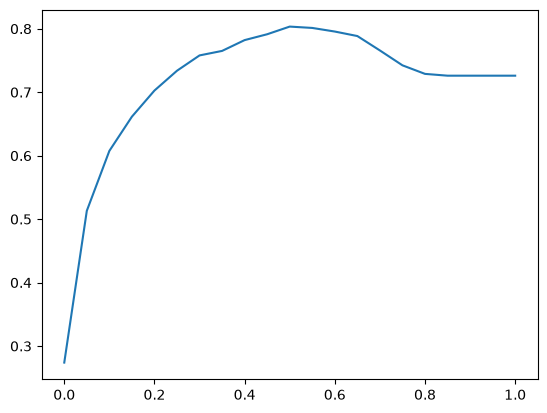

In [10]:
# evaluate the model on different thresholds
thresholds = np.linspace(0, 1, 21)

scores = []
for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('Treshold: %.2f - Accuracy: %.3f' % (t, score))
    scores.append(score)

# plot accuracy scores
plt.plot(thresholds, scores)

In [12]:
from collections import Counter

# Count predictions above/below the threshold
print(Counter(y_pred >= 1.0))

# Proportion of class 0 in the validation set
# = accuracy of always predicting 0
print(1 - y_val.mean())

Counter({np.False_: 1409})
0.7260468417317246


### Part 3: Confusion Table

In [ ]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

t = 0.5
predict_positive = (y_pred >= t)
predict_negative = (y_pred < t)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix

(confusion_matrix / confusion_matrix.sum()).round(2)

### Part 4: Precision and Recall

In [ ]:
p = tp / (tp + fp)
p

In [ ]:
r = tp / (tp + fn)
r

### Part 5: ROC Curves
#### TPR and FRP

#### Random Model

#### Ideal Model

#### Result

### Part 6: ROC AUC

### Part 7: Cross-Validation